# Two-dimensional assignments for different cost exponents

This notebook generates `fig:matching-2d-cost-exponent`. It uses the canonical two-dimensional point-cloud pair shared by several early figures: a semi-regular source sampled in a central disk and a semi-regular target sampled on a thin annulus. For the same clouds, we solve
$$
\min_{\sigma\in\operatorname{Perm}(n)} \frac1n\sum_{i=1}^n \|x_i-y_{\sigma(i)}\|^p
$$
for $p=1/2,1,2,6$.


In [1]:
from pathlib import Path
import sys

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
import ot

from figure_style import (
    VIOLET,
    canonical_matching_clouds,
    draw_point_clouds,
    draw_transport_segments,
    figure_dir,
    padded_limits,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()


## Canonical source and target clouds

The source is uniform on a central disk and the target is uniform on an annulus. Farthest-point sampling makes the clouds nearly regular; a small random perturbation avoids a rigid lattice and makes crossings and long edges easier to read.


In [2]:
alpha, beta, beta_labels = canonical_matching_clouds(seed=2027, n_source=36)

all_points = np.vstack([alpha, beta])
xlim, ylim = padded_limits(all_points, pad=0.18)
D = np.linalg.norm(alpha[:, None, :] - beta[None, :, :], axis=2)
a = np.ones(len(alpha)) / len(alpha)
b = np.ones(len(beta)) / len(beta)


## Assignments and export

For equal weights and equal cardinality, the optimal transport plan is a permutation matrix.  We export one axis-free panel per exponent so LaTeX can assemble the comparison.

In [3]:
fig_name = "matching-2d-cost-exponent"
out = figure_dir(fig_name)

for p, filename in [(0.5, "p0p5.pdf"), (1, "p1.pdf"), (2, "p2.pdf"), (6, "p6.pdf")]:
    plan = ot.emd(a, b, D ** p, numItermax=200000)
    pairs = [(i, j, float(plan[i, j])) for i in range(plan.shape[0]) for j in range(plan.shape[1]) if plan[i, j] > 1e-10]

    fig, ax = plt.subplots(figsize=(2.25, 2.25))
    draw_transport_segments(ax, alpha, beta, pairs, color=VIOLET, min_width=0.34, max_width=0.34, alpha_scale=0.50, zorder=1)
    draw_point_clouds(ax, alpha, beta, base_size=13.0, zorder=3)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    remove_axes(ax)
    save_pdf(fig, out / filename, pad_inches=0.042)
    plt.close(fig)


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


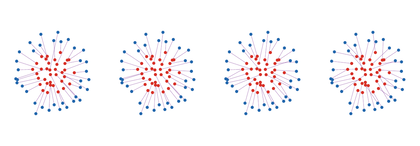

In [4]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/matching-2d-cost-exponent.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/matching-2d-cost-exponent.png")
display(Image(filename=str(_thumb)))
